In [1]:
from runsims_FNL import * 

-----------------------------------------------------
SarahLibanore: developed f_nl in IC and fcoll, fixed on 06/17/2026
-----------------------------------------------------


In [ ]:
Lbox_fid = 300
Nbox_fid = 150

Fiducial case:
- Edgeworth expression in dNion_General
- D'Alosio expression in dNdm_conditional
- Only popII 
- Scale-independent fnl
- Max cut at log10 M = 12

Let's first run the Gaussian case in the fiducial setup

In [ ]:
Gauss = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = 0., 
            force_mmax = 14., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = False, 
            nongauss_fcollcond = False, 
            nongauss_fcolluncond = False, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

# Test 1: Gaussian vs Non-Gaussian in our fiducial scenario

Compare:

- Gauss
- Non-Gauss

using a test value of fnl

In [4]:
fnl_test = 200.

In [ ]:
NG = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = fnl_test, 
            force_mmax = 14., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = True, 
            nongauss_fcollcond = True, 
            nongauss_fcolluncond = True, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

In [ ]:
NGm = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = -fnl_test, 
            force_mmax = 14., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = True, 
            nongauss_fcollcond = True, 
            nongauss_fcolluncond = True, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

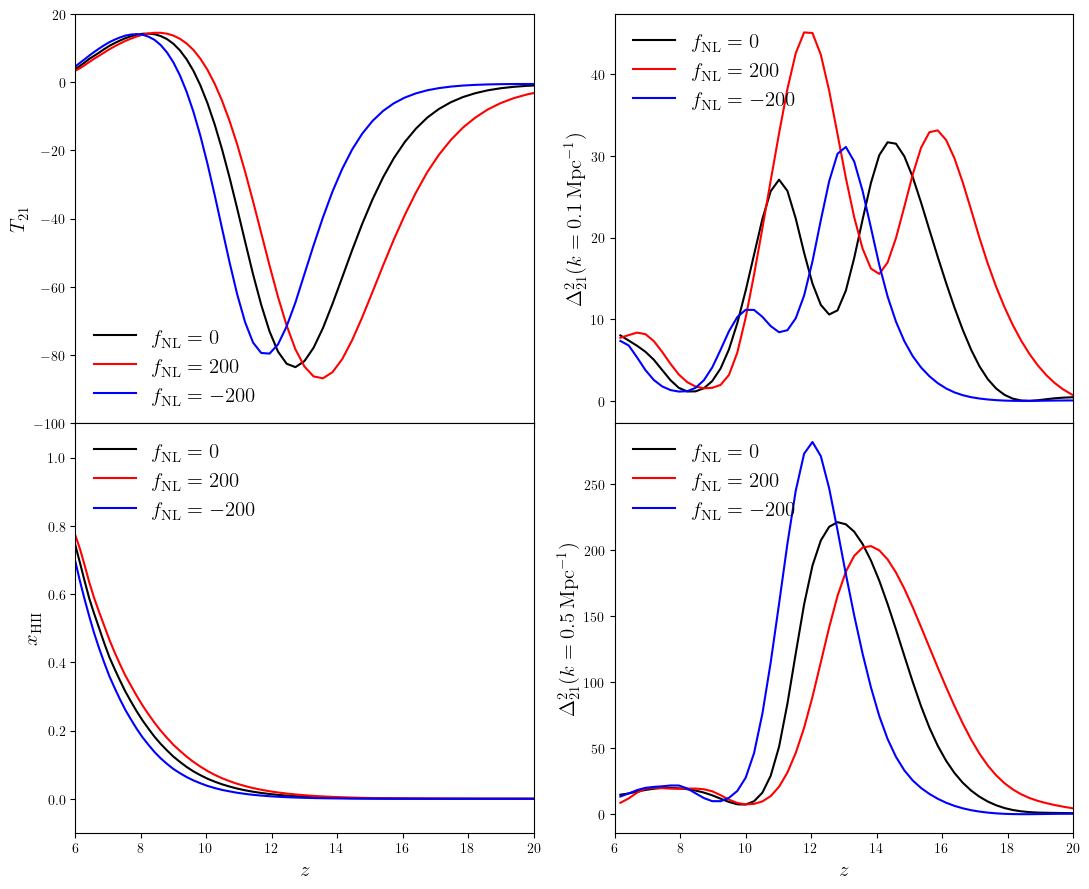

In [7]:
compare = [Gauss, NG, NGm]

plot_compare_multi(k_vals = [0.1,0.5], 
                    list_to_compare = compare,
                    list_colors = ['k', 'r', 'b'],
                    list_ls = ['-', '-','-'],
                    list_labels = [
                        r'$f_{\rm NL}=0$',
                        r'$f_{\rm NL}=%g$'%fnl_test,
                        r'$f_{\rm NL}=%g$'%(-fnl_test)
                    ], 
                    filename = 'compare_NG_fiducial_' + str(Lbox_fid) + ',' + str(Nbox_fid) + '.png')

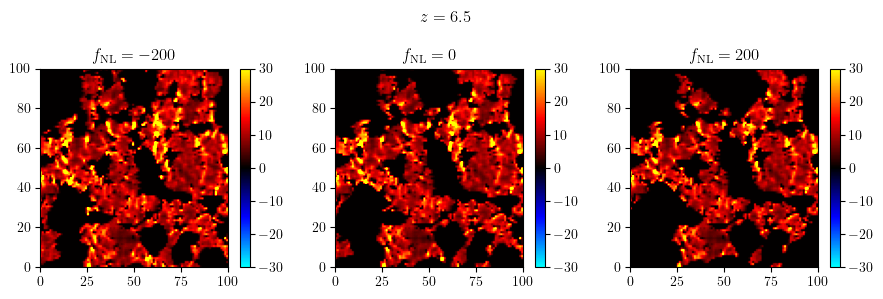

In [8]:
plot_compare_boxes(0,100,compare,                    
                   list_labels = [
                        r'$f_{\rm NL}=0$',
                        r'$f_{\rm NL}=%g$'%fnl_test,
                        r'$f_{\rm NL}=%g$'%(-fnl_test)
                    ], 
                    filename = 'boxes_NG_fiducial_' + str(Lbox_fid) + ',' + str(Nbox_fid) + '.png')

# Test 5: CutOff Mass

Compare: 
- Gauss cut off at log10 M = 12 (fid)
- Gauss integrated over the full mass array
- Non-Gauss cut off at log10 M = 12 (fid)
- Non-Gauss cut off at log10 M = 14
- Non-Gauss integrated over the full mass array

In [26]:
Gauss_full = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = 0., 
            force_mmax = 0., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = False, 
            nongauss_fcollcond = False, 
            nongauss_fcolluncond = False, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

In [29]:
NG_full = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = fnl_test, 
            force_mmax = 0., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = True, 
            nongauss_fcollcond = True, 
            nongauss_fcolluncond = True, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

File not found: ./final_test/100,100,200.0.pkl
Running...
Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...
Now going through the dark ages...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [13:24<00:00,  9.57s/redshift]


In [30]:
NGm_full = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = fnl_test, 
            force_mmax = 0., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = True, 
            nongauss_fcollcond = True, 
            nongauss_fcolluncond = True, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

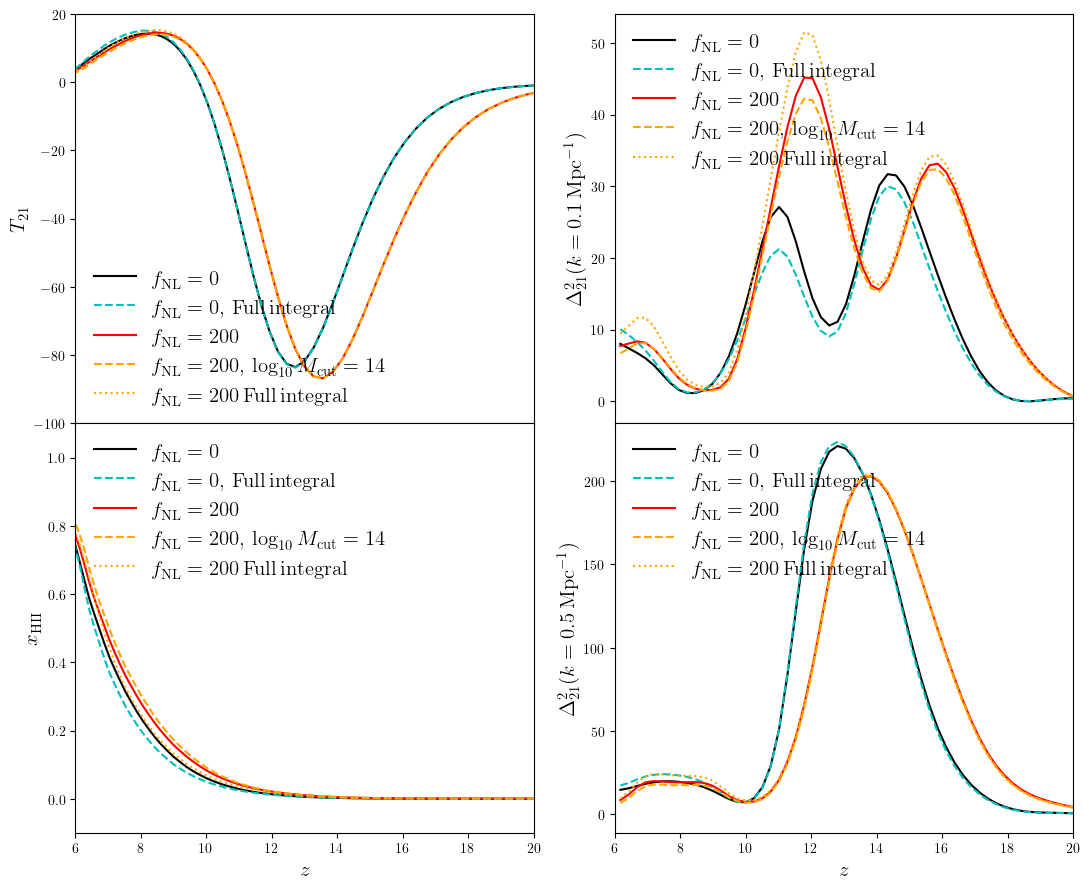

In [ ]:
compare = [Gauss, Gauss_full, NG, NG_full]

plot_compare_multi(k_vals = [0.1,0.5], 
                    list_to_compare = compare,
                    list_colors = ['k', 'c', 'r', 'orange','orange'],
                    list_ls = ['-', '--','-','--',':'],
                    list_labels = [
                        r'$f_{\rm NL}=0$',
                        r'$f_{\rm NL}=0,\,\rm Full\,integral$',
                        r'$f_{\rm NL}=%g$'%fnl_test,
                        r'$f_{\rm NL}=%g,\,\log_{10}M_{\rm cut}=14$'%fnl_test,
                        r'$f_{\rm NL}=%g\,\rm Full\,integral$'%fnl_test,
                    ], 
                    filename = 'compare_Mcutoff_' + str(Lbox_fid) + ',' + str(Nbox_fid) + '.png')